In [2]:
import numpy as np
import matplotlib.pyplot as plt

points={
    'a':(1, 2), 'b':(2, 5), 'c':(3, 2), 'd':(5, 4), 'e':(4, 7),
    'f':(6, 7), 'g':(8, 3), 'h':(10, 4), 'i':(12, 1), 'j':(10, 0)
}
X=np.array(list(points.values()))
labels=list(points.keys())

print(X)
print(labels)



[[ 1  2]
 [ 2  5]
 [ 3  2]
 [ 5  4]
 [ 4  7]
 [ 6  7]
 [ 8  3]
 [10  4]
 [12  1]
 [10  0]]
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']


In [5]:
initial_centroids=np.array([points['a'], points['e'], points['i']])

distance_iter1 =np.sqrt(((X[:, np.newaxis] - initial_centroids) ** 2).sum(axis=2))
clusters_iter1 = np.argmin(distance_iter1, axis=1)

print("-- Les clusters apres la premiere iteration--")
for k in range (3):
    class_points= [labels[i] for i, cluster_id in enumerate(clusters_iter1) if cluster_id == k]
    print(f"Classe {k+1}: {class_points}")


-- Les clusters apres la premiere iteration--
Classe 1: ['a', 'c']
Classe 2: ['b', 'd', 'e', 'f']
Classe 3: ['g', 'h', 'i', 'j']


In [8]:
new_centroids = np.array([X[clusters_iter1 == k].mean(axis=0) for k in range(3)])

distance_iter2=np.sqrt(((X[:, np.newaxis] - new_centroids) ** 2).sum(axis=2))
final_cluster=np.argmin(distance_iter2, axis=1)

print("-- Classes finales --")
for k in range (3):
    class_points= [labels[i] for i, cluster_id in enumerate(final_cluster) if cluster_id == k]
    print(f"Classe {k+1}: {class_points}")

-- Classes finales --
Classe 1: ['a', 'c']
Classe 2: ['b', 'd', 'e', 'f']
Classe 3: ['g', 'h', 'i', 'j']


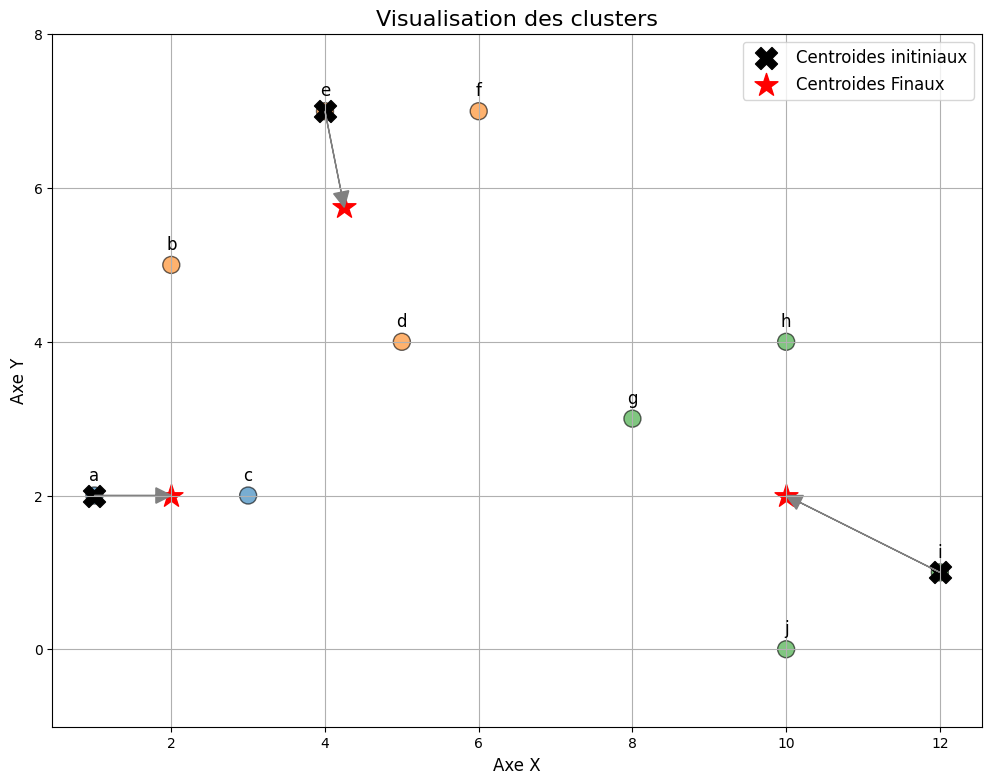

In [12]:
plt.figure(figsize=(12,9))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
cluster_colors=[colors[c] for c in final_cluster]

plt.scatter(X[:, 0], X[:, 1], c=cluster_colors, s=150, alpha=0.6, edgecolors='k')

for i, label in enumerate(labels):
    plt.text(X[i, 0], X[i, 1] + 0.2, label, fontsize=12, ha='center')

plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1], c='black', marker='X', s=250, label='Centroides initiniaux')
plt.scatter(new_centroids[:, 0], new_centroids[:, 1], c='red', marker="*", s=300, label='Centroides Finaux')

for i in range(3):
    plt.arrow(initial_centroids[i, 0], initial_centroids[i, 1], new_centroids[i, 0] - initial_centroids[i, 0], new_centroids[i, 1] - initial_centroids[i, 1], head_width=0.2, head_length=0.2, fc='gray', ec='gray', length_includes_head=True)

plt.title('Visualisation des clusters', fontsize=16)
plt.xlabel('Axe X', fontsize=12)
plt.ylabel('Axe Y', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.axis('equal')
plt.show()